In [261]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [262]:
# Import functions from src directory (src is ../src)
import sys
import pandas as pd
import numpy as np
sys.path.append('../src')

from download_TC_data import download_storm_forecast, extract_gzip
from preprocess_TC_data import clean_track_data, clean_track_data2
from utils import track_interpolation, cyclone_velocity, cyclone_bearing
from visualization import make_trajectory_animation, plot_trajectory
from generate_exposure import generate_synthetic_portfolio


In [263]:
forecast_path = extract_gzip(download_storm_forecast(2018, 'al', '14', deck='a'))

Year is 2018. Checking ARCHIVE source...


91it [00:01, 66.35it/s]


Downloaded to /Users/wirths/Documents/Private/NatCat/src/../data/raw/aal142018.dat.gz
Extracted to /Users/wirths/Documents/Private/NatCat/src/../data/raw/aal142018.dat


In [264]:
df_forcast = clean_track_data2(forecast_path, is_best_track=False)
df_forcast

Looking for TECH column with value 'OFCL'


/Users/wirths/Documents/Private/NatCat/notebooks/../src/preprocess_TC_data.py:67: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None, names=col_names, sep=",", skipinitialspace=True, on_bad_lines='warn')


,TECH,timestamp,tau,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,min_pressure_mb,storm_type
781,AVNO,2018-10-05 18:00:00,0,16.2,-84.5,23,88.0,1008,XX
782,AVNO,2018-10-05 18:00:00,6,16.8,-85.0,21,110.0,1007,XX
783,AVNO,2018-10-05 18:00:00,12,16.4,-85.8,23,136.0,1007,XX
784,AVNO,2018-10-05 18:00:00,18,15.5,-85.8,26,160.0,1006,XX
785,AVNO,2018-10-05 18:00:00,24,16.5,-85.8,31,93.0,1007,XX
...,...,...,...,...,...,...,...,...,...
58608,AVNO,2018-10-12 12:00:00,60,47.4,-13.4,39,154.0,991,XX
58609,AVNO,2018-10-12 12:00:00,66,46.2,-11.6,33,160.0,998,XX
58610,AVNO,2018-10-12 12:00:00,72,44.4,-9.9,28,152.0,1005,XX
58611,AVNO,2018-10-12 12:00:00,78,43.5,-9.2,25,157.0,1009,XX


In [45]:
clean_track_data("/Users/wirths/Documents/Private/NatCat/data/raw/bal142018.dat", is_best_track=True)

,timestamp,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,min_pressure_mb,storm_type
0,2018-10-06 18:00:00,17.8,-86.6,25,90,1006,LO
1,2018-10-07 00:00:00,18.1,-86.9,25,90,1004,LO
2,2018-10-07 06:00:00,18.4,-86.8,30,120,1004,TD
3,2018-10-07 12:00:00,18.8,-86.4,35,120,1003,TS
4,2018-10-07 18:00:00,19.1,-85.7,45,60,999,TS
...,...,...,...,...,...,...,...
80,2018-10-15 00:00:00,45.9,-13.5,55,90,982,EX
81,2018-10-15 06:00:00,44.4,-11.4,50,90,989,EX
82,2018-10-15 06:00:00,44.4,-11.4,50,90,989,EX
83,2018-10-15 12:00:00,42.8,-10.3,35,90,996,EX


In [265]:
df_OFCL = df_forcast[df_forcast['TECH'] == 'OFCL'].copy()
df_OFCL.tau

7654      0
7655      3
7656     12
7657     24
7658     36
         ..
57325    36
57326    36
57327    48
57328    48
57329    72
Name: tau, Length: 386, dtype: int64

In [266]:
df_OFCL.timestamp.unique()

<DatetimeArray>
['2018-10-06 18:00:00', '2018-10-07 00:00:00', '2018-10-07 06:00:00',
 '2018-10-07 12:00:00', '2018-10-07 18:00:00', '2018-10-08 00:00:00',
 '2018-10-08 06:00:00', '2018-10-08 12:00:00', '2018-10-08 18:00:00',
 '2018-10-09 00:00:00', '2018-10-09 06:00:00', '2018-10-09 12:00:00',
 '2018-10-09 18:00:00', '2018-10-10 00:00:00', '2018-10-10 06:00:00',
 '2018-10-10 12:00:00', '2018-10-10 18:00:00', '2018-10-11 00:00:00',
 '2018-10-11 06:00:00', '2018-10-11 12:00:00', '2018-10-11 18:00:00',
 '2018-10-12 00:00:00', '2018-10-12 06:00:00']
Length: 23, dtype: datetime64[ns]

In [46]:
def extract_past_trajectory(df,timestamp, tech='OFCL'):
    df_ptrac = df[df['TECH'] == tech].copy()
    df_ptrac = df_ptrac[df_ptrac['timestamp'] <= timestamp]
    df_ptrac = df_ptrac[df_ptrac['tau'] == 0]

    # Remove duplicates
    df_ptrac = df_ptrac.drop_duplicates(subset=['timestamp'], keep='last')
    
    return df_ptrac

def extract_future_trajectory(df,timestamp, tech='OFCL'):
    df_ftrac = df[df['TECH'] == tech].copy()
    df_ftrac = df_ftrac[df_ftrac['timestamp'] == timestamp]
    #df_ftrac = df_ftrac[df_ftrac['tau'] != 0]

    # Remove duplicates
    df_ftrac = df_ftrac.drop_duplicates(subset=['tau'], keep='last')

    # Add tau to timestamp to get future timestamps
    df_ftrac['timestamp'] = df_ftrac['timestamp'] + pd.to_timedelta(df_ftrac['tau'], unit='h')
    
    return df_ftrac

In [51]:
# trusted_models = ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX']


df_test_OFCL = extract_past_trajectory(df_forcast, '2018-10-08 00:00:00')
df_test_AVNO = extract_past_trajectory(df_forcast, '2018-10-08 00:00:00', tech='AVNO')
df_test_EMXI = extract_past_trajectory(df_forcast, '2018-10-08 00:00:00', tech='EMXI')
df_test_HWRF = extract_past_trajectory(df_forcast, '2018-10-08 00:00:00', tech='HWRF')
df_test_CTCX = extract_past_trajectory(df_forcast, '2018-10-08 00:00:00', tech='CTCX')
df_test_UKX = extract_past_trajectory(df_forcast, '2018-10-08 00:00:00', tech='UKX')

df_ftest_OFCL = extract_future_trajectory(df_forcast, '2018-10-08 00:00:00')
df_ftest_AVNO = extract_future_trajectory(df_forcast, '2018-10-08 00:00:00', tech='AVNO')
df_ftest_EMXI = extract_future_trajectory(df_forcast, '2018-10-08 00:00:00', tech='EMXI')
df_ftest_HWRF = extract_future_trajectory(df_forcast, '2018-10-08 00:00:00', tech='HWRF')
df_ftest_CTCX = extract_future_trajectory(df_forcast, '2018-10-08 00:00:00', tech='CTCX')
df_ftest_UKX = extract_future_trajectory(df_forcast, '2018-10-08 00:00:00', tech='UKX')
df_ftest_AVNO.head()

,TECH,timestamp,tau,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,min_pressure_mb
21086,AVNO,2018-10-08 00:00:00,0,19.7,-85.5,39,0.0,998
21087,AVNO,2018-10-08 06:00:00,6,20.3,-85.5,45,0.0,994
21089,AVNO,2018-10-08 12:00:00,12,21.3,-85.4,51,0.0,986
21092,AVNO,2018-10-08 18:00:00,18,22.1,-85.8,66,0.0,980
21095,AVNO,2018-10-09 00:00:00,24,23.0,-85.7,69,0.0,970


The data has 0 past points and 0 future points.


/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  result = super().scatter(*args, **kwargs)


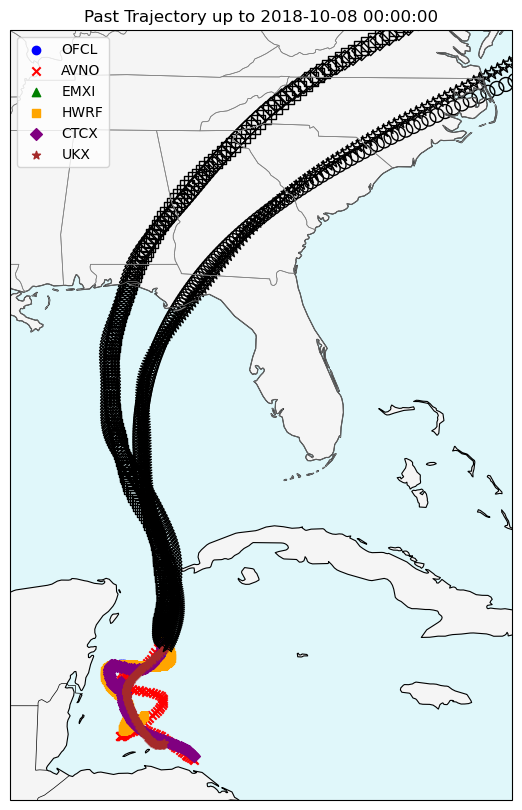

In [77]:
# We can now plot the trajectories of the past and the forcasted future 
_ = plot_trajectory(df_forcast, ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX'], '2018-10-08 00:00:00')

/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  result = super().scatter(*args, **kwargs)


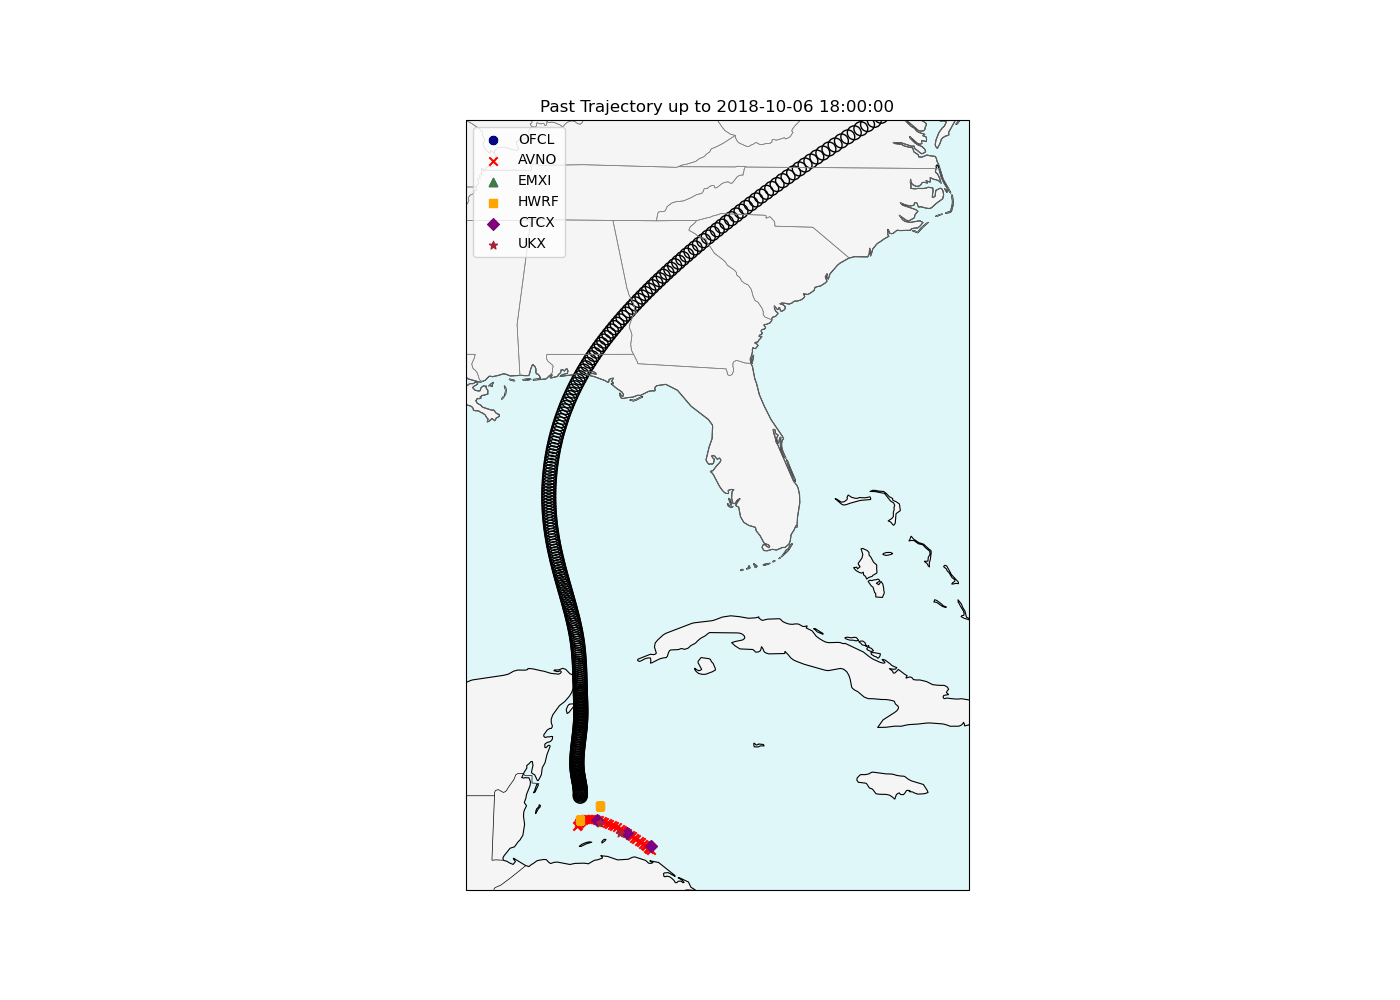

In [73]:
# Also as animation
_ = make_trajectory_animation(df_forcast, df_OFCL)

In [289]:
def prepare_track_data(df, timestamp, model, avail=1, past=True):
    if past:
        df_out = extract_past_trajectory(df, timestamp, tech=model)
    else: 
        df_out = extract_future_trajectory(df, timestamp, tech=model)

    df_out = get_heuristic_rmw(df_out)
    try:
        df_out = track_interpolation(df_out, time_step='30min', kind='cubic')
    except:
        avail = 0

    #Drop low wind speed columns
    #df_out = df_out[df_out['max_wind_speed_kt'] >= 40].reset_index(drop=True)
    # Add cyclone bearing and velocity
    df_out = cyclone_velocity(df_out)
    df_out = cyclone_bearing(df_out)

    return df_out, avail

def get_heuristic_rmw(df):
    df_fixed = df.copy()
    winds = df_fixed['max_wind_speed_kt'].fillna(0)
    storm_type = df_fixed['storm_type'] 


    # We do a simple windspeed to radius mapping: e.g. <35kt -> 80nm, <64kt -> 60nm, <96kt -> 40nm, <137kt -> 25nm, else 15nm
    conditions = [
        winds < 35,   
        winds < 64,   
        winds < 96,   
        winds < 137   
    ]

    choices = [
        80.0, 
        60.0,  
        40.0,  
        25.0   
    ]
    
    heuristic_rmw = np.select(conditions, choices, default=15.0)
    needs_fix_mask = (df_fixed['radius_max_wind_nm'].isna()) | (df_fixed['radius_max_wind_nm'] <= 0)

    df_fixed.loc[needs_fix_mask, 'radius_max_wind_nm'] = heuristic_rmw[needs_fix_mask]

    # We also aply a flat 1.5 scaling for extratropical cyclones
    ex_mask = df_fixed['storm_type'] == 'EX'
    df_fixed.loc[ex_mask, 'radius_max_wind_nm'] *= 1.5
        
    return df_fixed

def portfolio_damage_model(df_tc_track, housing_portfolio, asymmetry_factor=1.0):
    """Calculates the damage to a housing portfolio given a tropical cyclone track."""
    from wind_fields import max_wind_speeds_at_locations
    from vulnerbility import get_damage_ratio
    # Get lon lat touples for portfolio
    points = list(zip(housing_portfolio['latitude'], housing_portfolio['longitude']))
    max_wind_speeds = max_wind_speeds_at_locations(df_tc_track, points, asymmetry_factor=asymmetry_factor)
    
    
    # Compute damage ratios based on the maximum wind speeds
    damage_ratios = get_damage_ratio(max_wind_speeds)

    portfolio_damages = damage_ratios * housing_portfolio['tiv']
    
    # Append portfolio damages to housing_portfolio dataframe
    housing_portfolio = housing_portfolio.copy()
    housing_portfolio['damage_ratio'] = damage_ratios
    housing_portfolio['damage'] = portfolio_damages

    return housing_portfolio


# Loss model for forcast 

# Inputs: 
from numpy import extract


housing_portfolio = generate_synthetic_portfolio(num_locs=1000)

def impact_tc_A_deck(df_tc_A_deck, housing_portfolio,timestamp=None, trusted_models = ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX'], full_report=False):
    """Calculates impact of a tropical cyclone given its A-deck data and a housing portfolio.
    If timestamp is provided, only considers past data up to that timestamp and forecasts from that point onward.
    
    Inputs: 
    - df_tc_A_deck: DataFrame containing the A-deck data of the tropical cyclone. (Already precleaned track data e.g. from clean_track_data2)
    - housing_portfolio: DataFrame containing the housing portfolio data.
    - timestamp: Optional; if provided, only considers data up to this timestamp.
    - trusted_models: List of trusted forecast models to consider.
    
    Outputs:"""
    import pandas as pd
    if timestamp is None:
        # Use latest timestamp as timestamp
        timestamp = df_tc_A_deck['timestamp'].max()
    
    df_past_list = []
    df_future_list = []

    history_avail = np.ones(len(trusted_models))
    future_avail = np.ones(len(trusted_models))
    
    for i, model in enumerate(trusted_models):
        
        # Past trajectory (initialization data)
        df_past, history_avail[i] = prepare_track_data(df_tc_A_deck, timestamp, model, avail=history_avail[i], past=True)
        df_past_list.append(df_past)

        # Future trajectory (forecasted data)
        df_future, future_avail[i] = prepare_track_data(df_tc_A_deck, timestamp, model, avail=future_avail[i], past=False)
        df_future_list.append(df_future)

    #return df_past_list, df_future_list, history_avail, future_avail
    past_damages = []
    future_damages = []
    for idx, model in enumerate(trusted_models):
        if history_avail[idx] == 1:
            df_past = df_past_list[idx]
            portfolio_damage = portfolio_damage_model(df_past, housing_portfolio)
            past_damages.append(portfolio_damage)

    for idx, model in enumerate(trusted_models):
        if future_avail[idx] == 1:
            df_future = df_future_list[idx]
            portfolio_damage = portfolio_damage_model(df_future, housing_portfolio)
            future_damages.append(portfolio_damage)
    

    return past_damages, future_damages, history_avail, future_avail

In [290]:
past_damages, future_damages, history_avail, future_avail = impact_tc_A_deck(df_forcast, housing_portfolio, timestamp='2018-10-10 00:00:00')

In [294]:
trusted_models = ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX']
index = df_OFCL['timestamp'].unique()
future_loss = pd.DataFrame(index=index, columns=trusted_models)
past_loss = pd.DataFrame(index=index, columns=trusted_models)


for timestamp in df_OFCL['timestamp'].unique():
    past_damages, future_damages, history_avail, future_avail = impact_tc_A_deck(df_forcast, housing_portfolio, timestamp=timestamp)
    
    # Map past damages to their corresponding models
    past_idx = 0
    for model_idx, model in enumerate(trusted_models):
        if history_avail[model_idx] == 1:
            past_damage_total = past_damages[past_idx]['damage'].sum()
            print(f"Timestamp: {timestamp}, Model: {model}, Past Damage: {past_damage_total}")
            past_loss.loc[timestamp, model] = past_damage_total
            past_idx += 1

    # Map future damages to their corresponding models
    future_idx = 0
    for model_idx, model in enumerate(trusted_models):
        if future_avail[model_idx] == 1:
            future_damage_total = future_damages[future_idx]['damage'].sum()
            future_loss.loc[timestamp, model] = future_damage_total
            future_idx += 1


Timestamp: 2018-10-06 18:00:00, Model: AVNO, Past Damage: 0.0
Timestamp: 2018-10-07 00:00:00, Model: AVNO, Past Damage: 0.0
Timestamp: 2018-10-07 00:00:00, Model: CTCX, Past Damage: 0.0
Timestamp: 2018-10-07 06:00:00, Model: AVNO, Past Damage: 0.0
Timestamp: 2018-10-07 06:00:00, Model: HWRF, Past Damage: 0.0
Timestamp: 2018-10-07 06:00:00, Model: CTCX, Past Damage: 0.0
Timestamp: 2018-10-07 12:00:00, Model: OFCL, Past Damage: 0.0
Timestamp: 2018-10-07 12:00:00, Model: AVNO, Past Damage: 0.0
Timestamp: 2018-10-07 12:00:00, Model: HWRF, Past Damage: 0.0
Timestamp: 2018-10-07 12:00:00, Model: CTCX, Past Damage: 0.0
Timestamp: 2018-10-07 12:00:00, Model: UKX, Past Damage: 0.0
Timestamp: 2018-10-07 18:00:00, Model: OFCL, Past Damage: 0.0
Timestamp: 2018-10-07 18:00:00, Model: AVNO, Past Damage: 0.0
Timestamp: 2018-10-07 18:00:00, Model: HWRF, Past Damage: 0.0
Timestamp: 2018-10-07 18:00:00, Model: CTCX, Past Damage: 0.0
Timestamp: 2018-10-07 18:00:00, Model: UKX, Past Damage: 0.0
Timestamp:

/var/folders/wx/t338ck_s4qz_jg5cr9mg00hc0000gn/T/ipykernel_56240/290127750.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cols = plt.cm.get_cmap('tab10', len(trusted_models))


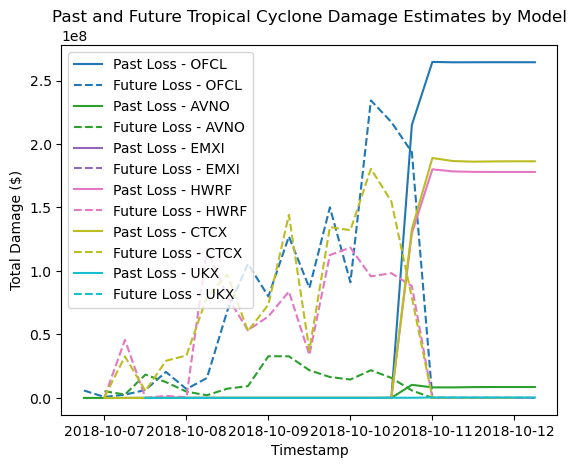

In [295]:
# Plot past and future loss for each model over time
import matplotlib.pyplot as plt
cols = plt.cm.get_cmap('tab10', len(trusted_models))
for i, model in enumerate(trusted_models):
    plt.plot(past_loss.index, past_loss[model], label=f'Past Loss - {model}', color=cols(i))
    plt.plot(future_loss.index, future_loss[model], linestyle='--', label=f'Future Loss - {model}', color=cols(i))

plt.xlabel('Timestamp')
plt.ylabel('Total Damage ($)')
plt.title('Past and Future Tropical Cyclone Damage Estimates by Model')
plt.legend()

In [217]:
past_damages[4].describe()

,location_id,latitude,longitude,tiv,damage_ratio,damage
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1.000000e+03
mean,500.500000,30.137334,-85.391579,3.366423e+05,0.561275,1.863928e+05
std,288.819436,0.379779,0.350628,1.784329e+05,0.413548,1.874378e+05
min,1.000000,29.506022,-85.996138,6.552873e+04,0.000000,0.000000e+00
25%,250.750000,29.806765,-85.710711,2.146410e+05,0.021257,6.548540e+03
50%,500.500000,30.145850,-85.377519,2.966871e+05,0.764334,1.640831e+05
75%,750.250000,30.467615,-85.087442,4.151200e+05,0.944948,2.850381e+05
max,1000.000000,30.799633,-84.800704,1.463811e+06,0.997463,1.364782e+06


In [229]:
df_future_list, df_future_list, history_avail, future_avail = impact_tc_A_deck(df_forcast, housing_portfolio, timestamp='2018-10-10 00:00:00')

In [235]:
df_future_list[5].describe()

,time,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,velocity_kt,bearing_deg
count,121,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,2018-10-11 06:00:00.000000256,32.460863,-82.071602,40.290246,63.537936,17.642412,65.036011
min,2018-10-10 00:00:00,26.700000,-86.589909,29.766081,51.308465,0.000000,0.000000
25%,2018-10-10 15:00:00,29.332031,-86.030729,34.575874,57.563786,12.047402,32.916908
50%,2018-10-11 06:00:00,32.466250,-83.390000,39.455908,61.638616,18.536012,46.332425
75%,2018-10-11 21:00:00,35.464844,-78.931771,45.271354,69.251029,20.427211,59.308723
max,2018-10-12 12:00:00,38.700000,-72.000000,53.453646,80.035896,32.170719,359.885456
std,NaN,3.506703,4.357896,7.158372,8.322842,5.987240,84.025538


In [238]:
past_damages[0]

,location_id,latitude,longitude,tiv,construction,damage_ratio,damage
0,1,29.986902,-85.777840,191187.27,Frame,0.0,0.0
1,2,30.735929,-85.349719,196135.26,Frame,0.0,0.0
2,3,30.451592,-84.952465,264808.06,Masonry,0.0,0.0
3,4,30.278256,-85.121330,356355.02,Frame,0.0,0.0
4,5,29.702824,-85.032127,468266.25,Frame,0.0,0.0
...,...,...,...,...,...,...,...
995,996,29.619057,-85.211654,223599.77,Masonry,0.0,0.0
996,997,30.692508,-84.852062,494198.06,Masonry,0.0,0.0
997,998,29.677864,-85.917250,842577.89,Frame,0.0,0.0
998,999,30.735309,-85.931534,134189.51,Frame,0.0,0.0


In [283]:
df_future_list[5].describe()

,time,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,velocity_kt,bearing_deg
count,121,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,2018-10-11 06:00:00.000000256,32.460863,-82.071602,40.290246,63.537936,17.642412,65.036011
min,2018-10-10 00:00:00,26.700000,-86.589909,29.766081,51.308465,0.000000,0.000000
25%,2018-10-10 15:00:00,29.332031,-86.030729,34.575874,57.563786,12.047402,32.916908
50%,2018-10-11 06:00:00,32.466250,-83.390000,39.455908,61.638616,18.536012,46.332425
75%,2018-10-11 21:00:00,35.464844,-78.931771,45.271354,69.251029,20.427211,59.308723
max,2018-10-12 12:00:00,38.700000,-72.000000,53.453646,80.035896,32.170719,359.885456
std,NaN,3.506703,4.357896,7.158372,8.322842,5.987240,84.025538
